# Disease Prediction Using Machine Learning

## CodeAlpha Machine Learning Internship

### Project Overview

Early disease prediction can assist healthcare professionals in making timely decisions by analyzing patient symptoms and medical attributes. This project develops a supervised machine learning model capable of predicting diseases based on patient data.

The project demonstrates the complete machine learning workflow, including data preprocessing, exploratory data analysis, model training, evaluation, and prediction.

## Objectives

The objectives of this project are:

- Understand the medical dataset.
- Perform data cleaning and preprocessing.
- Explore the dataset through visualization.
- Train multiple machine learning models.
- Compare model performance.
- Select the best-performing model.
- Predict diseases using new patient information.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Joblib
- Jupyter Notebook (VS Code)

## Table of Contents

1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis
4. Data Preprocessing
5. Feature Engineering
6. Train-Test Split
7. Model Training
8. Model Comparison
9. Model Evaluation
10. Save Best Model
11. Disease Prediction
12. Conclusion

# Import Libraries

The following libraries are imported for data manipulation, visualization, machine learning model development, evaluation, and model persistence.

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Save Model
import joblib

# Load the Dataset

The Heart Disease dataset is obtained directly from the UCI Machine Learning Repository using the official `ucimlrepo` package. This ensures the dataset source is authentic and reproducible.

In [4]:
from ucimlrepo import fetch_ucirepo

# Fetch Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

# Features and target
X = heart_disease.data.features
y = heart_disease.data.targets

# Combine into one DataFrame
df = X.copy()
df["target"] = y

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


# Dataset Overview

Before building machine learning models, it is important to understand the dataset's structure, features, and quality.

This section explores:
- Dataset dimensions
- Feature names
- Data types
- Statistical summary
- Missing values

In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (303, 14)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

## Observations

- The dataset contains clinical information for heart disease prediction.
- Features include patient demographics, chest pain type, blood pressure, cholesterol level, ECG results, and other medical measurements.
- Missing values, if present, will be handled during preprocessing.
- The target variable indicates the presence of heart disease.

# Data Cleaning

Data cleaning is an essential preprocessing step before training machine learning models.

In this section, we will:

- Check for missing values.
- Handle missing values appropriately.
- Verify duplicate records.
- Prepare the dataset for exploratory data analysis and model training.

In [10]:
# Check missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [11]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# Handling Missing Values

The dataset contains a small number of missing values in the `ca` and `thal` features.

Since both variables represent categorical/discrete medical attributes, missing values are replaced using the **mode (most frequent value)**. This preserves the integrity of the dataset without removing valuable samples.

In [14]:
# Fill missing values using mode

# Fill missing values using mode

df["ca"] = df["ca"].fillna(df["ca"].mode()[0])
df["thal"] = df["thal"].fillna(df["thal"].mode()[0])

In [15]:
# Verify missing values after preprocessing

df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

# Target Variable Analysis

The target variable represents the diagnosis of heart disease.

Before training machine learning models, we analyze the distribution of the target classes to understand the dataset balance.

In [16]:
# Display target value counts

df["target"].value_counts().sort_index()

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

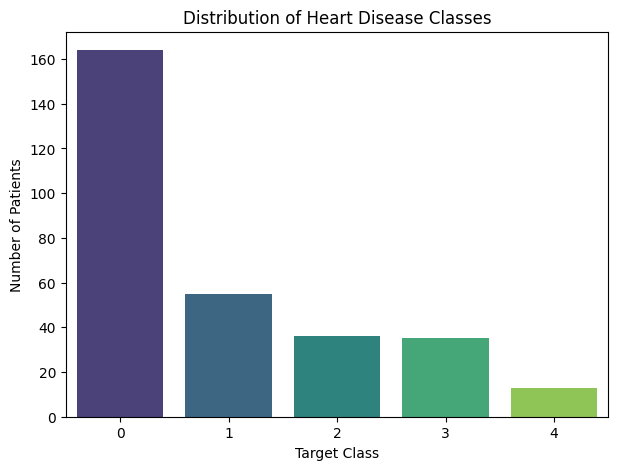

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="target",
    palette="viridis"
)

plt.title("Distribution of Heart Disease Classes")
plt.xlabel("Target Class")
plt.ylabel("Number of Patients")

plt.show()

# Target Variable Preprocessing

The original target variable contains five classes (0–4), where 0 indicates the absence of heart disease and 1–4 represent increasing severity levels.

For this project, the target variable is converted into a binary classification problem:

- **0:** No Heart Disease
- **1:** Heart Disease

This simplifies the prediction task and makes the model suitable for early disease screening.

In [18]:
# Convert multiclass target to binary

df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)

df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

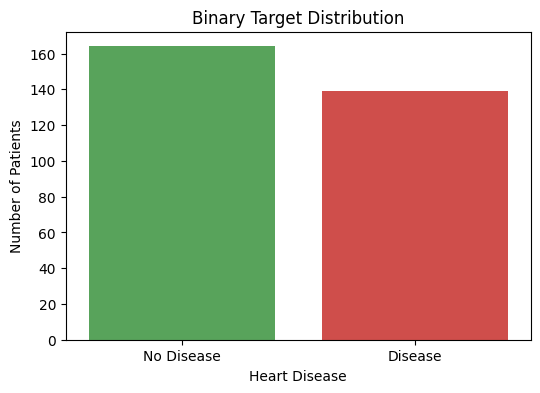

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="target",
    hue="target",
    palette=["#4CAF50", "#E53935"],
    legend=False
)

plt.title("Binary Target Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.xticks([0,1],["No Disease","Disease"])

plt.show()